# CORnet → video → EEG-alignment pipeline

Refined pipeline ported from `cornet_test.ipynb` (CORnet-only core; the
Ridge/Lasso/MLP EEG-regression exploration is intentionally left out).

**What it does, per subject (`sub1`–`sub8`):**
1. Load the pretrained **CORnet-S** model (CPU) and hook the four cortical areas
   **V1 → V2 → V4 → IT**.
2. Open the head-mounted **camera video** and sample frames two ways:
   - **event-locked** — one frame at every `UP`/`IN` face event, and
   - **random** — frames drawn throughout the analysis window (exploratory; also
     the groundwork for future object-detection-locked sampling).

   The **analysis window** is restricted to the first stimulus → last stimulus,
   padded by `WINDOW_PAD_S` (default 1 s) either side, then clipped to the video
   bounds and to where the EEG epoch fits. Event-locked frames are the stimuli
   themselves; random frames are sampled within this window.
3. Push each frame through CORnet and flatten the per-layer activations.
4. **Align to EEG**: the preprocessed `.set` file is 500 Hz and embeds the cleaned
   `UP`/`IN` face events as annotations. Video start (`T 1`) is read from each
   subject's `Triggers.xlsx` (column B = trigger label, column C directly to its
   right = EEG samples from EEG start to that trigger). Each sheet has two `T 1`
   rows — video **start** (earliest) and video **end** (latest); we take the
   earliest. The `.set` only retained a `T 1` annotation for some subjects, so the
   spreadsheet is the source of truth (cross-checked against the `.set` when
   present). Then `t_video = t_eeg − t_T1` and `frame ≈ round(t_video × fps)`; for
   every sampled frame we record the EEG sample index and extract an EEG epoch.

The endpoint here is **aligned feature + EEG arrays** saved per subject — RSA /
encoding modelling is a downstream step, not part of this notebook.

## Video choice: original vs stabilised + central crop

This notebook uses the **original** `s<N>_corrected.mp4` (`USE_STABILISED_VIDEO = False`).
Switching to the Shotcut-stabilised `_shotcut.mp4` would also want a central crop to
avoid the edge distortion the dataset documentation warns about.

**Original `s<N>_corrected.mp4` (used here)**
- *Pros:* full 960×540 field of view, no stabilisation warp; CORnet sees the true
  scene including peripheral context, and low-level features (V1/V2) are unperturbed.
- *Cons:* head motion means the same face/scene lands at different positions and
  scales across frames, injecting representational noise unrelated to stimulus
  identity — which can dilute any frame↔EEG correspondence.

**Stabilised `_shotcut.mp4` + central crop**
- *Pros:* stabilisation (max shakiness/accuracy, smoothing 10) holds a face more
  spatially consistent across frames — better representational stability and a
  better base for future object-locked sampling.
- *Cons:* documented edge distortion forces a central crop, which discards
  peripheral context and changes effective scale/FOV; the warp itself perturbs
  low-level features, hitting early layers (V1/V2) hardest.

**Bottom line:** start with the original for an unbiased baseline. Because the source
is a single config flag, the stabilised+crop variant can be re-run and compared later.

## Comparing cropped vs uncropped

Everything above runs on whichever frames `CROP_FACE` selected. To compare the two:

1. Run the whole notebook once with `CROP_FACE = False` (full frames →
   `sub<N>_cornet.npz`).
2. Set `CROP_FACE = True` in **Configuration**, re-run from the run-loop cell down
   (face-cropped frames → `sub<N>_cornet_facecrop.npz`).

The RDM and RSA cells will then reflect the cropped frames. The two runs save to
different files, so neither overwrites the other; if cropping helps, the combined RSA
curve should lift above its full-frame version and the split UP/IN panels become the
proper test of the orientation hypothesis on face-centred input. (If you want both sets
of curves on screen at once, the analysis functions still accept an explicit
`results=` store — load the two `.npz` sets into separate dicts and pass each in.)

In [1]:
import os
import random
import zipfile
from pathlib import Path
from xml.etree import ElementTree as ET

import numpy as np
import cv2
import torch
import torchvision.transforms as transforms
from PIL import Image
import mne
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_distances
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr

import cornet

mne.set_log_level("ERROR")

## Configuration

In [2]:
def _find_data_root():
    "Locate 'data/SUBJECT eeg data' walking up from the current working dir."
    here = Path.cwd().resolve()
    for base in [here, *here.parents]:
        cand = base / "data" / "SUBJECT eeg data"
        if cand.exists():
            return cand
    raise FileNotFoundError("Could not locate 'data/SUBJECT eeg data' from cwd")


DATA_ROOT = _find_data_root()
SUBJECTS = range(1, 9)
LAYERS = ["V1", "V2", "V4", "IT"]   # early -> late ventral stream

# ImageNet preprocessing (CORnet was trained with these stats)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
IMG_SIZE = 224

# EEG: 64 scalp channels, then x/y/z accelerometers + FaceInversion regressor.
N_EEG_CHANNELS = 64
EPOCH_TMIN, EPOCH_TMAX = -2.0, 2.0   # seconds around each frame (matches preprocessing)

N_RANDOM_FRAMES = 100
RANDOM_SEED = 42

# Analysis window = first stimulus -> last stimulus, padded by this many seconds
# either side (then clipped to video bounds and where the EEG epoch fits).
WINDOW_PAD_S = 1.0

# Use the original corrected video. Flip to True for the Shotcut-stabilised
# version (see the trade-offs note at the bottom of the notebook).
USE_STABILISED_VIDEO = False

# Frame content fed to CORnet:
#   False -> full (letterboxed) frame; CORnet sees the whole cluttered scene.
#   True  -> per-frame face crop (Haar detector, inversion-robust); CORnet sees
#            mostly the face. See the "Face cropping" section for the rationale.
# This drives the whole pipeline below; cropped/uncropped runs save to different
# files (sub<N>_cornet.npz vs sub<N>_cornet_facecrop.npz), so you can flip it,
# re-run, and keep both. Set per-call too: run_subject(sub, crop_face=...).
CROP_FACE = False

RESULTS_DIR = DATA_ROOT.parent / "cornet_analysis_outputs"
RESULTS_DIR.mkdir(exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("RESULTS_DIR:", RESULTS_DIR)

DATA_ROOT: /Users/ansonliu/Github/vision_proc_networks/data/SUBJECT eeg data
RESULTS_DIR: /Users/ansonliu/Github/vision_proc_networks/data/cornet_analysis_outputs


## CORnet-S model + forward hooks

In [3]:
# Pretrained weights were authored for GPU; force CPU loading via torch.load.
# Guard so re-running this cell doesn't wrap the patch around itself (which would
# cause infinite recursion -> RecursionError).
if not getattr(torch.load, "_cpu_patched", False):
    _original_torch_load = torch.load

    def _cpu_torch_load(*args, **kwargs):
        kwargs["map_location"] = torch.device("cpu")
        return _original_torch_load(*args, **kwargs)

    _cpu_torch_load._cpu_patched = True
    torch.load = _cpu_torch_load

model = cornet.cornet_s(pretrained=True)
model.eval()

# CORnet is wrapped in nn.DataParallel; cortical areas live under `.module`.
activations = {}


def _get_activation(name):
    def hook(_module, _inp, output):
        activations[name] = output.detach()

    return hook


# Remove any hooks from a previous run of this cell before re-registering.
for _h in globals().get("_hook_handles", []):
    _h.remove()

_hook_handles = [
    getattr(model.module, layer).register_forward_hook(_get_activation(layer))
    for layer in LAYERS
]
print("CORnet-S loaded on CPU; hooks on", LAYERS)

CORnet-S loaded on CPU; hooks on ['V1', 'V2', 'V4', 'IT']


/Users/ansonliu/Github/vision_proc_networks/.venv/lib/python3.12/site-packages/torch/serialization.py:1865: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  result = unpickler.load()


## Frame preprocessing & feature extraction

In [4]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


def frame_to_features(rgb_frame):
    "RGB uint8 ndarray (H, W, 3) -> {layer: flattened float32 activation vector}."
    img = Image.fromarray(rgb_frame)
    x = transform(img).unsqueeze(0)
    with torch.no_grad():
        _ = model(x)
    return {layer: activations[layer].flatten().cpu().numpy() for layer in LAYERS}

## Video helpers

In [5]:
def video_path(sub):
    suffix = "_shotcut" if USE_STABILISED_VIDEO else ""
    return DATA_ROOT / f"sub{sub}" / f"s{sub}_corrected{suffix}.mp4"


def open_video(sub):
    cap = cv2.VideoCapture(str(video_path(sub)))
    if not cap.isOpened():
        raise FileNotFoundError(f"Could not open video for sub{sub}: {video_path(sub)}")
    fps = cap.get(cv2.CAP_PROP_FPS)
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    return cap, fps, n_frames


def grab_frame(cap, t_sec, fps):
    "Return the RGB frame at video time t_sec, or None if out of range."
    frame_idx = int(round(t_sec * fps))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ok, bgr = cap.read()
    if not ok:
        return None
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

## Face cropping (used when `CROP_FACE = True`)

This is a **mobile/walking task**: the head-cam shows printed B&W face portraits on
walls/noticeboards, surrounded by posters and text, inside a **letterboxed** frame
(black bars where portrait footage was rotated into a landscape video). With the full
frame, CORnet's representation is dominated by **scene/background** differences rather
than the face, leaving little face-specific structure for the EEG to match (the
full-frame RSA sits at noise level).

Setting `CROP_FACE = True` makes `run_subject` crop each frame to the face first:

- **Detection:** OpenCV's Haar frontal-face cascade, run on the frame **and its 180°
  rotation**, keeping the largest hit. Faces vary a lot in position/scale (head motion),
  so a fixed box is unsuitable. Running both orientations means inverted (`IN`) faces
  are found about as reliably as upright (`UP`) ones — crucial, since an upright-only
  detector would silently bias the very UP-vs-IN contrast we test. The rotation only
  *locates* the face; the crop is taken in the **original** orientation, so UP stays
  upright and IN stays inverted.
- **Crop:** a square around the face plus margin (context), then CORnet's 224×224
  resize. If no face is found, fall back to the **central square** (faces are roughly
  centred horizontally; this also drops the black side-bars).
- Detection isn't perfect for every subject (the run loop reports per-subject hit
  rates), and fallback frames still contain scene context — so cropped input is
  *cleaner*, not clean.

In [6]:
_FACE_CASCADE = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml")


def detect_face_bbox(rgb, scale_factor=1.1, min_neighbors=5, min_size=50):
    # Largest face box (x, y, w, h) in ORIGINAL-frame coords, or None.
    # Run on the frame AND its 180-rotated copy so inverted faces are found as
    # reliably as upright ones; rotation only LOCATES the face, the crop keeps
    # the original orientation.
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    H, W = gray.shape
    best, best_area = None, 0
    for rot in (0, 180):
        g = gray if rot == 0 else cv2.rotate(gray, cv2.ROTATE_180)
        faces = _FACE_CASCADE.detectMultiScale(
            g, scaleFactor=scale_factor, minNeighbors=min_neighbors,
            minSize=(min_size, min_size))
        for (x, y, w, h) in faces:
            if rot == 180:
                x, y = W - x - w, H - y - h
            if w * h > best_area:
                best_area, best = w * h, (int(x), int(y), int(w), int(h))
    return best


def crop_to_face(rgb, bbox, margin=0.6):
    # Square crop around the face (+margin), orientation preserved. No face ->
    # central square (drops the black letterbox bars, faces are ~centred).
    H, W = rgb.shape[:2]
    if bbox is None:
        s = min(H, W)
        return rgb[(H - s) // 2:(H - s) // 2 + s, (W - s) // 2:(W - s) // 2 + s]
    x, y, w, h = bbox
    cx, cy = x + w / 2.0, y + h / 2.0
    s = min(int(round(max(w, h) * (1.0 + margin))), H, W)
    x0 = int(round(min(max(cx - s / 2.0, 0), W - s)))
    y0 = int(round(min(max(cy - s / 2.0, 0), H - s)))
    return rgb[y0:y0 + s, x0:x0 + s]

## Trigger spreadsheet (video-start) helpers

In [7]:
_XLSX_NS = "{http://schemas.openxmlformats.org/spreadsheetml/2006/main}"


def _read_xlsx_sheet(path):
    "Dependency-free .xlsx reader: list of {column_letter: value} per row."
    z = zipfile.ZipFile(path)
    strings = []
    try:
        tree = ET.fromstring(z.read("xl/sharedStrings.xml"))
        for si in tree.findall(_XLSX_NS + "si"):
            strings.append("".join(n.text or "" for n in si.iter(_XLSX_NS + "t")))
    except KeyError:
        pass
    sheet = ET.fromstring(z.read("xl/worksheets/sheet1.xml"))
    rows = []
    for row in sheet.find(_XLSX_NS + "sheetData").findall(_XLSX_NS + "row"):
        cells = {}
        for c in row.findall(_XLSX_NS + "c"):
            v = c.find(_XLSX_NS + "v")
            if v is None:
                continue
            val = strings[int(v.text)] if c.get("t") == "s" else v.text
            col = "".join(ch for ch in c.get("r") if ch.isalpha())
            cells[col] = val
        rows.append(cells)
    return rows


def video_start_sample(sub):
    # Column B = trigger label, column C (directly right) = EEG samples from EEG
    # start to that trigger. Each sheet has two 'T 1' rows: video start (earliest)
    # and video end (latest); we take the earliest.
    rows = _read_xlsx_sheet(DATA_ROOT / f"sub{sub}" / "Triggers.xlsx")
    samples = [
        int(r["C"]) for r in rows
        if str(r.get("B", "")).strip().upper().replace(" ", "") == "T1" and "C" in r
    ]
    if not samples:
        raise ValueError(f"No 'T 1' trigger found in sub{sub} Triggers.xlsx")
    return min(samples)

## EEG / event helpers

In [8]:
FACE_LABELS = {"UP": "upright", "IN": "inverted"}


def eeg_path(sub):
    return DATA_ROOT / f"sub{sub}" / "RmIaf_mobileface.set"


def load_eeg(sub):
    return mne.io.read_raw_eeglab(str(eeg_path(sub)), preload=True)


def get_t1(sub, raw):
    # Video-start time (s from EEG start), read from Triggers.xlsx (authoritative,
    # present for all subjects). The .set only retained a 'T 1' annotation for
    # some subjects; where it has one, cross-check and warn on mismatch.
    sf = raw.info["sfreq"]
    t1 = video_start_sample(sub) / sf
    mne_t1 = [
        float(o) for o, d in zip(raw.annotations.onset, raw.annotations.description)
        if d.strip().upper().replace(" ", "") == "T1"
    ]
    if mne_t1 and abs(min(mne_t1) - t1) > 0.1:
        print(f"  sub{sub}: WARNING xlsx T1={t1:.3f}s vs .set T1={min(mne_t1):.3f}s")
    return t1


def get_face_events(raw):
    "Sorted list of (onset_s, 'UP'|'IN') for the face events."
    out = [
        (float(onset), desc.strip().upper())
        for onset, desc in zip(raw.annotations.onset, raw.annotations.description)
        if desc.strip().upper() in FACE_LABELS
    ]
    return sorted(out, key=lambda x: x[0])


def eeg_epoch(raw, t_eeg):
    "(N_EEG_CHANNELS, n_times) array around EEG time t_eeg, or None if OOB."
    sf = raw.info["sfreq"]
    start = int(round((t_eeg + EPOCH_TMIN) * sf))
    stop = int(round((t_eeg + EPOCH_TMAX) * sf))
    if start < 0 or stop > raw.n_times:
        return None
    data = raw.get_data(picks=list(range(N_EEG_CHANNELS)), start=start, stop=stop)
    return data.astype(np.float32)

## Per-subject pipeline

In [9]:
def run_subject(sub, n_random_frames=N_RANDOM_FRAMES, seed=RANDOM_SEED, crop_face=False):
    # crop_face=True runs each frame through the face detector and crops to the face
    # before CORnet (see the face-crop section); otherwise the full frame is used.
    raw = load_eeg(sub)
    sf = raw.info["sfreq"]
    eeg_dur = raw.n_times / sf
    t1 = get_t1(sub, raw)
    face_events = get_face_events(raw)
    cap, fps, n_frames = open_video(sub)
    video_dur = n_frames / fps
    rng = random.Random(seed + sub)

    records = []

    def add_frame(t_eeg, label, kind):
        t_video = t_eeg - t1
        if t_video < 0 or t_video > video_dur:
            return False
        frame = grab_frame(cap, t_video, fps)
        if frame is None:
            return False
        face_found = None
        if crop_face:
            bbox = detect_face_bbox(frame)
            face_found = bbox is not None
            frame = crop_to_face(frame, bbox)
        records.append({
            "kind": kind,
            "label": label,
            "t_eeg": t_eeg,
            "t_video": t_video,
            "eeg_sample": int(round(t_eeg * sf)),
            "face_found": face_found,            # None unless crop_face=True
            "features": frame_to_features(frame),
            "epoch": eeg_epoch(raw, t_eeg),   # None near recording edges
        })
        return True

    # 1) Event-locked frames (one per UP/IN face event)
    for t_eeg, label in face_events:
        add_frame(t_eeg, label, kind="event")

    # 2) Random frames across the analysis window: first stimulus -> last stimulus
    #    padded by WINDOW_PAD_S, clipped to video bounds and where the epoch fits.
    win_lo = win_hi = None
    if face_events:
        win_lo = max(face_events[0][0] - WINDOW_PAD_S, t1, -EPOCH_TMIN)
        win_hi = min(face_events[-1][0] + WINDOW_PAD_S, t1 + video_dur, eeg_dur - EPOCH_TMAX)
        for _ in range(n_random_frames):
            if win_hi <= win_lo:
                break
            add_frame(rng.uniform(win_lo, win_hi), "random", kind="random")

    cap.release()
    return {
        "sub": sub, "fps": fps, "t1": t1, "sfreq": sf,
        "eeg_dur": eeg_dur, "video_dur": video_dur,
        "window": (win_lo, win_hi), "crop_face": crop_face,
        "n_face_events": len(face_events), "records": records,
    }

## Run all subjects & save aligned outputs

In [10]:
def save_subject(res):
    "Write per-subject features, labels, EEG samples and epochs to a .npz."
    recs = res["records"]
    save = {}
    for kind in ("event", "random"):
        kr = [r for r in recs if r["kind"] == kind]
        for layer in LAYERS:
            save[f"{kind}_{layer}"] = (
                np.array([r["features"][layer] for r in kr])
                if kr else np.empty((0, 0), dtype=np.float32)
            )
        save[f"{kind}_labels"] = np.array([r["label"] for r in kr])
        save[f"{kind}_t_eeg"] = np.array([r["t_eeg"] for r in kr], dtype=float)
        save[f"{kind}_t_video"] = np.array([r["t_video"] for r in kr], dtype=float)
        save[f"{kind}_eeg_sample"] = np.array([r["eeg_sample"] for r in kr], dtype=int)
        epochs = [r["epoch"] for r in kr]
        mask = np.array([e is not None for e in epochs])
        good = [e for e in epochs if e is not None]
        save[f"{kind}_epochs"] = np.stack(good) if good else np.empty((0, 0, 0), dtype=np.float32)
        save[f"{kind}_epoch_mask"] = mask
    save["meta_fps"] = res["fps"]
    save["meta_t1"] = res["t1"]
    save["meta_sfreq"] = res["sfreq"]
    save["meta_window"] = np.array(res["window"], dtype=float)  # (lo, hi) EEG seconds
    suffix = "_facecrop" if res.get("crop_face") else ""
    np.savez_compressed(RESULTS_DIR / f"sub{res['sub']}_cornet{suffix}.npz", **save)

In [11]:
# CROP_FACE (set in Configuration) decides whether frames are face-cropped. Cropped
# and uncropped runs save to different files, so flip CROP_FACE, re-run, keep both.
print(f"CROP_FACE = {CROP_FACE}")
all_results = {}
for sub in SUBJECTS:
    try:
        res = run_subject(sub, crop_face=CROP_FACE)
    except Exception as e:  # keep the batch going if one subject is unreadable
        print(f"sub{sub}: SKIPPED ({type(e).__name__}: {e})")
        continue
    all_results[sub] = res
    save_subject(res)

    recs = res["records"]
    n_event = sum(r["kind"] == "event" for r in recs)
    n_random = sum(r["kind"] == "random" for r in recs)
    it_dim = recs[0]["features"]["IT"].shape[0] if recs else 0
    win = res["window"]
    win_str = f"[{win[0]:.1f},{win[1]:.1f}]s" if win[0] is not None else "n/a"
    crop_str = ""
    if CROP_FACE:
        ev = [r for r in recs if r["kind"] == "event"]
        det = sum(bool(r["face_found"]) for r in ev)
        crop_str = f" faces={det}/{len(ev)}"
    print(f"sub{sub}: t1={res['t1']:.2f}s fps={res['fps']:.1f} window={win_str} "
          f"events={n_event}/{res['n_face_events']} random={n_random} IT_dim={it_dim}{crop_str}")

print("\nSaved outputs to", RESULTS_DIR)

CROP_FACE = False
sub1: t1=18.56s fps=25.0 window=[18.6,384.5]s events=45/46 random=100 IT_dim=25088
sub2: t1=5.35s fps=25.0 window=[16.1,311.3]s events=61/61 random=100 IT_dim=25088
sub3: t1=30.57s fps=30.0 window=[43.0,502.1]s events=64/64 random=100 IT_dim=25088
sub4: t1=11.58s fps=30.0 window=[32.5,497.2]s events=74/74 random=100 IT_dim=25088
sub5: t1=11.50s fps=30.0 window=[11.5,486.6]s events=76/78 random=100 IT_dim=25088
sub6: t1=6.41s fps=30.0 window=[25.8,693.0]s events=104/104 random=100 IT_dim=25088
sub7: t1=10.78s fps=30.0 window=[10.8,619.5]s events=78/80 random=100 IT_dim=25088
sub8: t1=17.57s fps=30.0 window=[17.6,1032.4]s events=140/142 random=100 IT_dim=25088

Saved outputs to /Users/ansonliu/Github/vision_proc_networks/data/cornet_analysis_outputs


## Inspect: representational dissimilarity (event-locked)

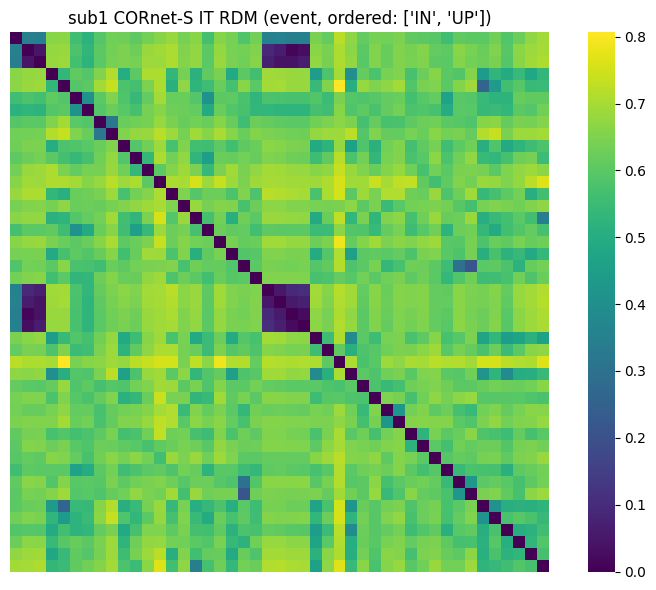

In [12]:
def _subject_list(subjects):
    "Accept an int or an iterable of subject ids -> sorted list of ints."
    if isinstance(subjects, (int, np.integer)):
        return [int(subjects)]
    return sorted(int(s) for s in subjects)


def _single_subject(subjects, what):
    subs = _subject_list(subjects)
    if len(subs) > 1:
        raise ValueError(
            f"{what} are per-subject: each subject saw different stimuli, so the "
            "RDM rows/columns aren't comparable and can't be averaged across "
            "subjects. Pass one subject; use plot_rsa_timecourse(...) for group "
            "(across-subject) results."
        )
    return subs[0]


def stack_features(sub, layer="IT", kind="event", results=None):
    results = all_results if results is None else results
    recs = [r for r in results[sub]["records"] if r["kind"] == kind]
    X = np.array([r["features"][layer] for r in recs])
    labels = [r["label"] for r in recs]
    return X, labels


def plot_rdm(subjects, layer="IT", kind="event", results=None):
    results = all_results if results is None else results
    sub = _single_subject(subjects, "Frame-level RDM heatmaps")
    recs = [r for r in results[sub]["records"] if r["kind"] == kind]
    order = sorted(range(len(recs)), key=lambda i: recs[i]["label"])  # block by condition
    X = np.array([recs[i]["features"][layer] for i in order])
    labels = sorted({recs[i]["label"] for i in order})
    rdm = cosine_distances(X)
    plt.figure(figsize=(8, 6))
    sns.heatmap(rdm, cmap="viridis", square=True, xticklabels=False, yticklabels=False)
    plt.title(f"sub{sub} CORnet-S {layer} RDM ({kind}, ordered: {labels})")
    plt.tight_layout()
    plt.show()


if all_results:
    plot_rdm(next(iter(all_results)), layer="IT", kind="event")

## Inspect: RDMs across the ventral-stream hierarchy (PLOT: do CORnet activations act similar for all upright vs inverted faces)

The same event-locked frames, but one RDM per layer (V1 → V2 → V4 → IT) on a shared
colour scale. Early layers (V1/V2) reflect low-level image structure; later layers
(V4/IT) reflect more abstract / object-level structure. Rows are ordered by
condition so any UP-vs-IN block structure is visible.

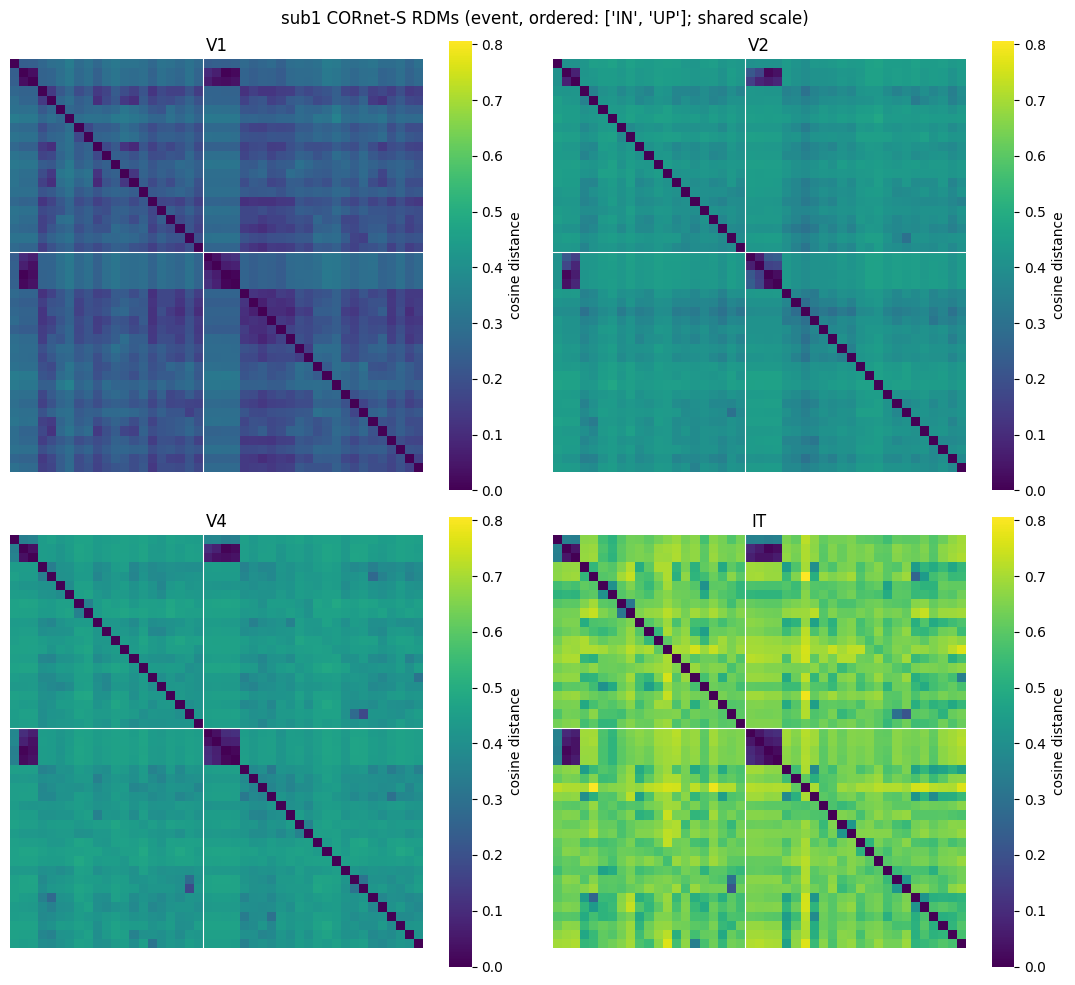

In [17]:
def plot_layer_rdms(subjects, kind="event", results=None):
    results = all_results if results is None else results
    sub = _single_subject(subjects, "Frame-level RDM heatmaps")
    recs = [r for r in results[sub]["records"] if r["kind"] == kind]
    order = sorted(range(len(recs)), key=lambda i: recs[i]["label"])  # block by condition
    labels = [recs[i]["label"] for i in order]
    rdms = {
        layer: cosine_distances(np.array([recs[i]["features"][layer] for i in order]))
        for layer in LAYERS
    }
    # boundary between the (sorted) conditions, for a guide line
    uniq = sorted(set(labels))
    split = labels.index(uniq[1]) if len(uniq) > 1 else None
    vmax = max(rdm.max() for rdm in rdms.values())

    fig, axes = plt.subplots(2, 2, figsize=(11, 10))
    for ax, layer in zip(axes.ravel(), LAYERS):
        sns.heatmap(rdms[layer], cmap="viridis", square=True, vmin=0, vmax=vmax,
                    xticklabels=False, yticklabels=False, ax=ax,
                    cbar_kws={"label": "cosine distance"})
        if split is not None:
            ax.axhline(split, color="w", lw=0.8)
            ax.axvline(split, color="w", lw=0.8)
        ax.set_title(layer)
    fig.suptitle(f"sub{sub} CORnet-S RDMs ({kind}, ordered: {uniq}; shared scale)")
    fig.tight_layout()
    plt.show()


if all_results:
    plot_layer_rdms(next(iter(all_results)), kind="event")

The below tells us what is wrong with the RDM. The images being compared don't even compare the correct stimuli

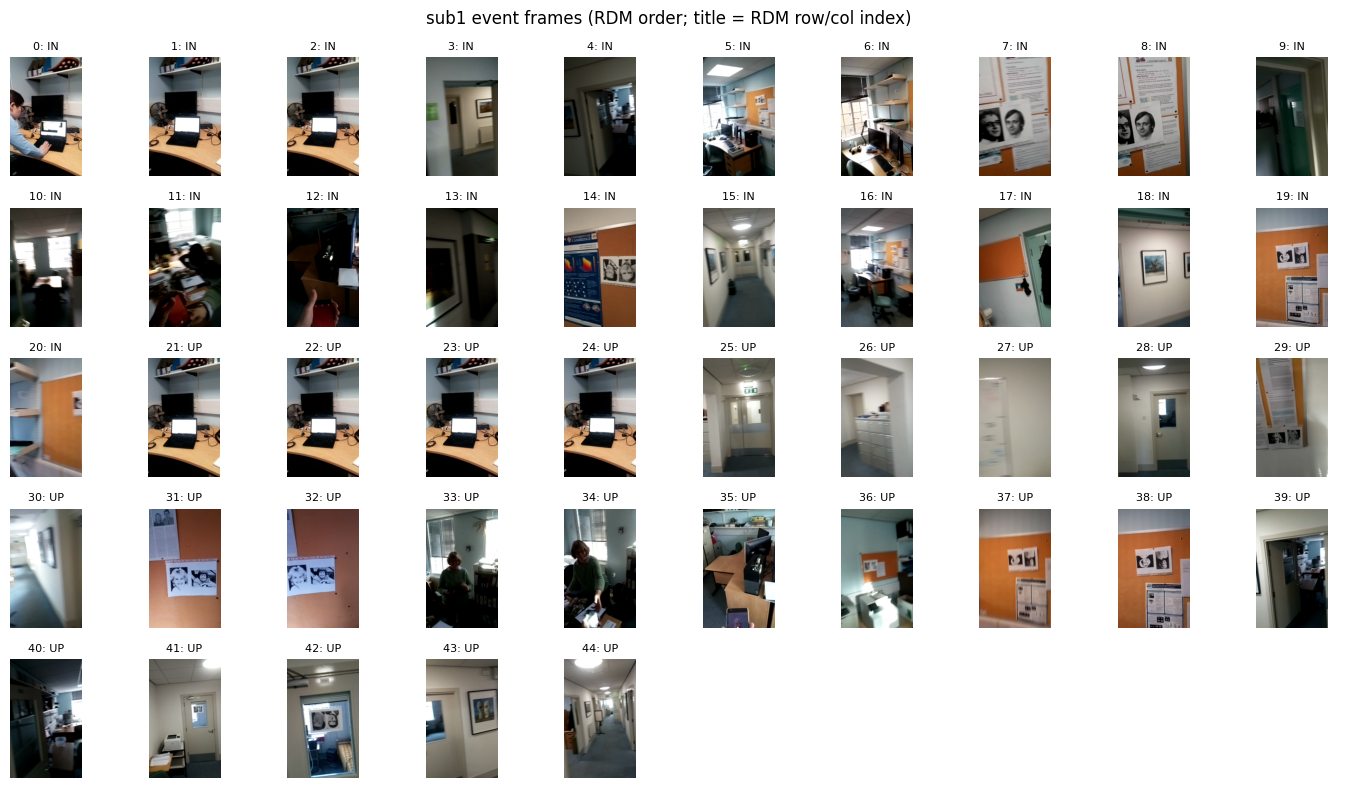

In [16]:
def plot_frame_gallery(subjects, kind="event", ncols=10, results=None):
    # Companion to plot_layer_rdms: the actual video frames behind each RDM row/col,
    # in the SAME label-sorted order, so a hot cell (i, j) can be traced back to the
    # two frames being compared. Frames aren't stored in the records, so they're
    # re-grabbed from the video by t_video. Caption = RDM index + label.
    results = all_results if results is None else results
    sub = _single_subject(subjects, "Frame galleries")
    recs = [r for r in results[sub]["records"] if r["kind"] == kind]
    if not recs:
        print(f"sub{sub}: no {kind} frames to show")
        return
    order = sorted(range(len(recs)), key=lambda i: recs[i]["label"])  # match RDM ordering

    cap, fps, _ = open_video(sub)
    try:
        frames = [grab_frame(cap, recs[i]["t_video"], fps) for i in order]
    finally:
        cap.release()

    n = len(order)
    nrows = -(-n // ncols)  # ceil
    fig, axes = plt.subplots(nrows, ncols, figsize=(1.4 * ncols, 1.6 * nrows))
    axflat = np.atleast_1d(axes).ravel()
    for ax in axflat:
        ax.axis("off")
    for pos, i in enumerate(order):
        ax = axflat[pos]
        if frames[pos] is not None:
            ax.imshow(frames[pos])
        ax.set_title(f"{pos}: {recs[i]['label']}", fontsize=8)
    fig.suptitle(f"sub{sub} {kind} frames (RDM order; title = RDM row/col index)")
    fig.tight_layout()
    plt.show()


if all_results:
    plot_frame_gallery(next(iter(all_results)), kind="event")


## RSA: does CORnet's representational geometry match the EEG?

- **Model RDM** (per layer): pairwise dissimilarity (correlation distance) between
  CORnet's activation vectors for every pair of frames. One N×N matrix per layer.
- **EEG RDM** (per time point): at each post-onset time sample, take the 64-channel
  scalp pattern for each event and compute the pairwise dissimilarity between events.
  One N×N matrix *per time point* — the EEG's representational geometry as it evolves.

**RSA** correlates the off-diagonal of the model RDM with the off-diagonal of the EEG
RDM (Spearman ρ). Two refinements over the crudest version:

- **Sliding time windows across the whole epoch.** Single 2 ms EEG samples are too
  noisy, so we average the scalp pattern within a sliding window (`window_ms`, default
  50 ms) that steps across the epoch (`step_ms`, default 10 ms). We deliberately do
  **not** lock to a fixed latency: a stimulus propagates V1→IT through the brain at
  different times, so each layer should match the EEG at its *own* latency. The whole
  V1→IT cascade is finished within ~300 ms of onset, so the sweep runs from a short
  pre-onset baseline (−200 ms) to **500 ms** by default (`end_ms`) rather than the full
  2 s epoch; the legend reports each layer's post-onset peak latency.
- **Group averaging.** `plot_rsa_timecourse`/`time_resolved_rsa` accept either one
  subject or a list. With a list, each subject contributes their own model+EEG RDMs
  and ρ time course (each over their own stimuli), and we average the **ρ curves**
  across subjects (shaded ±SEM). This is the correct group RSA — you average the
  second-level statistic, never the subject-specific RDMs.

A bump after 0 s means CORnet and the brain organise the stimuli the same way at that
latency; if the hierarchy is reflected in time you'd expect earlier layers (V1) to
peak earlier than later layers (IT). The pre-onset stretch should sit near zero — a
built-in sanity check.

Caveats: still no permutation/cluster statistics, no EEG noise-normalization, and the
frames are whole cluttered scenes — treat the curves as exploratory.

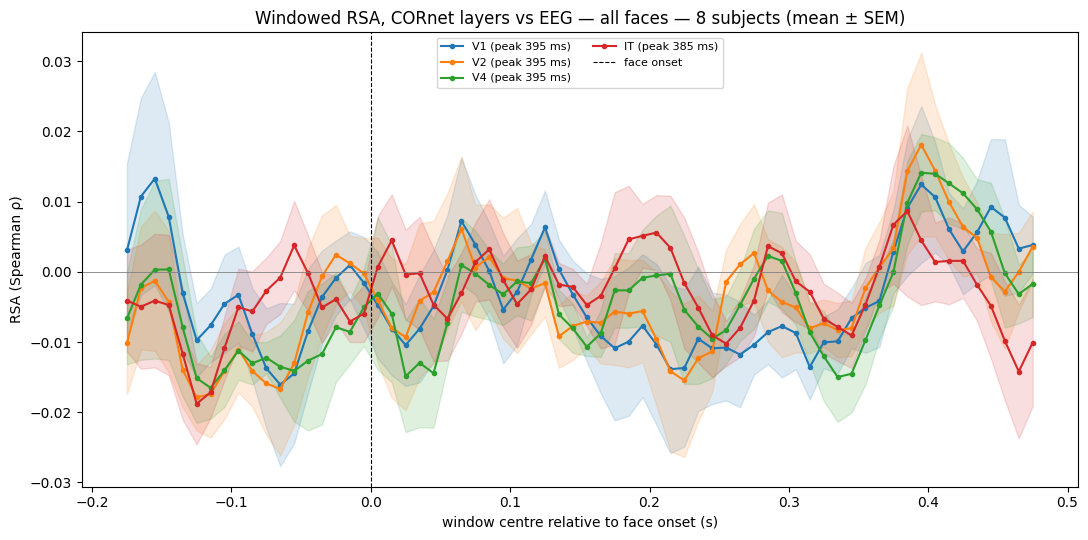

In [14]:
def _subject_windowed_rsa(sub, layers, metric, win_edges, conditions=None, results=None):
    # Per-subject windowed RSA -> {layer: rho per window} over valid event epochs.
    # conditions: optional iterable of labels (e.g. {"UP"}) to restrict the RDM rows
    # to one face type; None uses all face events (UP+IN combined).
    results = all_results if results is None else results
    res = results[sub]
    recs = [r for r in res["records"] if r["kind"] == "event" and r["epoch"] is not None]
    if conditions is not None:
        keep = {c.strip().upper() for c in conditions}
        recs = [r for r in recs if r["label"].strip().upper() in keep]
    if len(recs) < 3:
        tag = "/".join(sorted(conditions)) if conditions else "event"
        raise ValueError(f"sub{sub}: too few valid {tag} epochs for RSA ({len(recs)})")
    model_rdms = {
        L: pdist(np.array([r["features"][L] for r in recs]), metric=metric)
        for L in layers
    }
    epochs = np.stack([r["epoch"] for r in recs])        # (n_events, 64, n_times)
    sf = res["sfreq"]
    times_ms = (np.arange(epochs.shape[2]) / sf + EPOCH_TMIN) * 1000.0
    out = {L: np.full(len(win_edges), np.nan) for L in layers}
    for k, (lo, hi) in enumerate(win_edges):
        sel = (times_ms >= lo) & (times_ms < hi)
        if not sel.any():
            continue
        eeg_rdm = pdist(epochs[:, :, sel].mean(axis=2), metric=metric)  # window-avg pattern
        if not np.all(np.isfinite(eeg_rdm)) or np.ptp(eeg_rdm) == 0:
            continue
        for L in layers:
            out[L][k] = spearmanr(model_rdms[L], eeg_rdm).correlation
    return out


def time_resolved_rsa(subjects, layers=LAYERS, metric="correlation",
                      window_ms=50.0, start_ms=-200.0, step_ms=10.0, end_ms=None,
                      conditions=None, results=None):
    # Windowed RSA swept across the epoch, averaged across subjects. Windows are not
    # locked to a fixed latency: each layer is free to peak at its own time.
    # conditions: optional set of face labels (e.g. {"UP"}) to build the RDMs over a
    # single face type; None combines UP+IN.
    # results: optional alternate store (a {sub: result} dict); None uses all_results.
    # Returns (window_centres_s, stats, n_subs); stats[layer] = (mean_rho, sem_rho).
    subs = _subject_list(subjects)
    step_ms = window_ms if step_ms is None else step_ms
    # The full V1->IT cascade unfolds within ~300 ms of onset, so sweep a short
    # baseline through 500 ms by default rather than the whole 2 s epoch.
    end_ms = 500.0 if end_ms is None else end_ms
    starts = np.arange(start_ms, end_ms - window_ms + 1e-6, step_ms)
    win_edges = [(s, s + window_ms) for s in starts]
    centres = np.array([(lo + hi) / 2 for lo, hi in win_edges]) / 1000.0  # seconds

    per_sub = {L: [] for L in layers}
    for sub in subs:
        r = _subject_windowed_rsa(sub, layers, metric, win_edges,
                                  conditions=conditions, results=results)
        for L in layers:
            per_sub[L].append(r[L])
    stats = {}
    for L in layers:
        arr = np.vstack(per_sub[L])                       # (n_subs, n_windows)
        sem = np.nanstd(arr, axis=0) / np.sqrt(max(arr.shape[0], 1))
        stats[L] = (np.nanmean(arr, axis=0), sem)
    return centres, stats, len(subs)


def _draw_rsa_curves(ax, centres, stats, n, layers, linestyle="-", marker="o",
                     label_suffix="", color_map=None):
    # Plot one ρ time course per layer onto ax; returns {layer: line_colour}.
    post = centres >= 0
    colours = {}
    for L in layers:
        mean, sem = stats[L]
        peak_lbl = f"{L}{label_suffix}"
        if post.any() and np.any(np.isfinite(mean[post])):
            pk = np.nanargmax(np.where(post, mean, np.nan))
            peak_lbl = f"{L}{label_suffix} (peak {centres[pk] * 1000:.0f} ms)"
        c = None if color_map is None else color_map.get(L)
        line, = ax.plot(centres, mean, marker=marker, ms=3, ls=linestyle,
                        color=c, label=peak_lbl)
        colours[L] = line.get_color()
        if n > 1:
            ax.fill_between(centres, mean - sem, mean + sem,
                            alpha=0.15, color=line.get_color())
    return colours


def _decorate_rsa_axis(ax, who, panel_title, ylabel=True):
    ax.axvline(0.0, color="k", lw=0.8, ls="--", label="face onset")
    ax.axhline(0.0, color="grey", lw=0.6)
    if ylabel:
        ax.set_ylabel("RSA (Spearman ρ)")
    ax.set_title(panel_title)
    ax.legend(fontsize=8, ncol=2)


def plot_rsa_timecourse(subjects, split_faces=False, **kw):
    # split_faces=False: one ρ curve per layer over all faces (UP+IN combined).
    # split_faces=True:  two stacked panels — upright faces above, inverted below —
    # to test whether they match CORnet's geometry differently.
    who = f"{len(_subject_list(subjects))} subjects (mean ± SEM)" \
        if len(_subject_list(subjects)) > 1 else f"sub{_subject_list(subjects)[0]}"
    if split_faces:
        c_up, stats_up, n = time_resolved_rsa(subjects, conditions={"UP"}, **kw)
        c_in, stats_in, _ = time_resolved_rsa(subjects, conditions={"IN"}, **kw)
        # shared y-scale so the two panels are directly comparable
        ymax = max(np.nanmax([m for m, _ in stats_up.values()]),
                   np.nanmax([m for m, _ in stats_in.values()]))
        ymin = min(np.nanmin([m for m, _ in stats_up.values()]),
                   np.nanmin([m for m, _ in stats_in.values()]))
        pad = 0.05 * (ymax - ymin + 1e-9)
        fig, (ax_up, ax_in) = plt.subplots(2, 1, figsize=(11, 9), sharex=True, sharey=True)
        _draw_rsa_curves(ax_up, c_up, stats_up, n, LAYERS)
        cols = {L: ax_up.get_lines()[i].get_color() for i, L in enumerate(LAYERS)}
        _draw_rsa_curves(ax_in, c_in, stats_in, n, LAYERS, color_map=cols)
        _decorate_rsa_axis(ax_up, who, "Upright faces (UP)")
        _decorate_rsa_axis(ax_in, who, "Inverted faces (IN)")
        ax_up.set_ylim(ymin - pad, ymax + pad)
        ax_in.set_xlabel("window centre relative to face onset (s)")
        fig.suptitle(f"Windowed RSA, CORnet layers vs EEG — UP vs IN — {who}")
    else:
        fig, ax = plt.subplots(figsize=(11, 5.5))
        centres, stats, n = time_resolved_rsa(subjects, **kw)
        _draw_rsa_curves(ax, centres, stats, n, LAYERS)
        _decorate_rsa_axis(ax, who, f"Windowed RSA, CORnet layers vs EEG — all faces — {who}")
        ax.set_xlabel("window centre relative to face onset (s)")
    fig.tight_layout()
    plt.show()


if all_results:
    # group-average across every subject loaded above
    plot_rsa_timecourse(sorted(all_results))

## RSA split by face orientation: upright vs inverted

Hypothesis: upright and inverted faces drive **different** representations, so they
should match CORnet's geometry differently. Here we rebuild the RSA separately for
each face type — model and EEG RDMs over **UP-only** frames, then over **IN-only**
frames — and show them as **two stacked panels** (upright above, inverted below) on a
shared axis scale so the layers line up for direct comparison. Everything else
(windowing, the no-fixed-lag sweep to 500 ms, across-subject averaging) is unchanged;
only the RDM rows are filtered.

Reading it: compare a given layer's curve top vs bottom — e.g. if IT rises higher for
UP than IN around the face-processing latency, that is evidence the orientation effect
is present in the shared model↔brain geometry. Note the per-condition RDMs use fewer
stimuli (only the UP or only the IN events), so each curve is noisier than the combined
one above; the combined plot stays the better-powered overall summary.

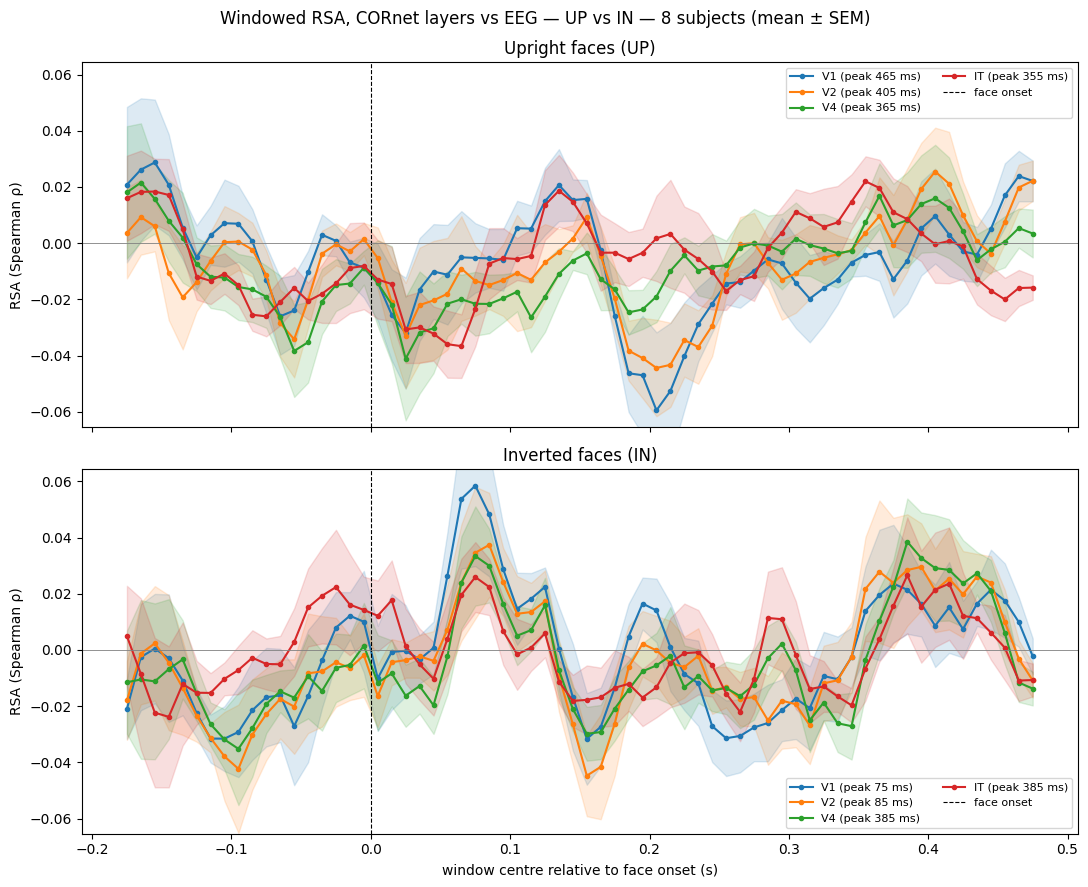

In [15]:
if all_results:
    plot_rsa_timecourse(sorted(all_results), split_faces=True)